# Smart Electricity Consumption Prediction & Energy Optimization System
### TEYZIX CORE Internship Program — Task ID: ML-3 (Machine Learning Domain)

**Author:** Khanum (Bushra) Khan — Sukkur IBA University, BS Computer Science (Batch 2026)
**Program:** DecodeLabs / TEYZIX CORE Internship, June Batch

This notebook documents the complete ML lifecycle for the project:
1. Original Dataset Creation
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Comparison (6 algorithms)
6. Model Evaluation
7. Prediction & Energy Optimization Recommendations
8. Report Generation

> **Note on dataset originality:** No public dataset (Kaggle/UCI/GitHub) is used. The dataset is
> generated using a physics-informed synthetic data model based on typical household appliance
> power ratings, described in Section 1 below.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', None)


## 1. Original Dataset Creation

We generate a realistic, original synthetic dataset of household electricity usage using a physics-informed additive model (see `src/generate_dataset.py` for full methodology).

In [2]:
from generate_dataset import generate_dataset

df_raw = generate_dataset()
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (656, 17)


,House_Type,Family_Members,Num_Rooms,AC_Usage_Hours,Fan_Usage_Hours,Fridge_Usage_Hours,Washing_Machine_Hours,Water_Motor_Hours,Lighting_Hours,Heater_Usage_Hours,TV_Electronics_Hours,Daily_Appliance_Count,Outdoor_Temperature_C,Day_of_Week,Season,Is_Working_Day,Daily_Electricity_Consumption_kWh
0,Apartment,1,1,0.0,5.7,22.9,1.16,0.49,6.1,0.7,0.0,3,24.4,Monday,Spring,1,9.49
1,Apartment,4,2,8.0,16.9,19.7,1.60,1.21,8.8,0.0,1.8,7,34.4,Wednesday,Summer,1,19.57
2,Independent House,2,1,4.0,16.0,20.7,0.67,0.53,4.5,0.7,0.0,3,32.1,Monday,Summer,1,12.57
3,Apartment,2,1,0.0,5.8,23.7,0.41,1.03,2.2,0.7,3.8,5,20.7,Monday,Spring,1,9.37
4,Independent House,8,5,1.6,7.4,21.9,1.39,1.35,6.6,0.4,5.3,11,20.9,Friday,Autumn,1,14.18


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   House_Type                         656 non-null    str    
 1   Family_Members                     656 non-null    int64  
 2   Num_Rooms                          656 non-null    int64  
 3   AC_Usage_Hours                     643 non-null    float64
 4   Fan_Usage_Hours                    656 non-null    float64
 5   Fridge_Usage_Hours                 656 non-null    float64
 6   Washing_Machine_Hours              656 non-null    float64
 7   Water_Motor_Hours                  656 non-null    float64
 8   Lighting_Hours                     643 non-null    float64
 9   Heater_Usage_Hours                 656 non-null    float64
 10  TV_Electronics_Hours               656 non-null    float64
 11  Daily_Appliance_Count              656 non-null    int64  
 12  Outdo

## 2. Data Preprocessing

Handling missing values, duplicates, outliers, encoding, and scaling.

In [4]:
from preprocessing import preprocess

df_processed, report = preprocess()
for k, v in report.items():
    print(f"{k}: {v}")
df_processed.head()


initial_rows: 656
duplicates_removed: 6
missing_values_imputed: 39
outliers_capped_per_column: {'Family_Members': 0, 'Num_Rooms': 0, 'AC_Usage_Hours': 0, 'Fan_Usage_Hours': 0, 'Fridge_Usage_Hours': 0, 'Washing_Machine_Hours': 0, 'Water_Motor_Hours': 0, 'Lighting_Hours': 0, 'Heater_Usage_Hours': 110, 'TV_Electronics_Hours': 0, 'Daily_Appliance_Count': 0, 'Outdoor_Temperature_C': 0, 'Daily_Electricity_Consumption_kWh': 2}
final_rows: 650
final_columns: 32


,House_Type,Family_Members,Num_Rooms,AC_Usage_Hours,Fan_Usage_Hours,Fridge_Usage_Hours,Washing_Machine_Hours,Water_Motor_Hours,Lighting_Hours,Heater_Usage_Hours,TV_Electronics_Hours,Daily_Appliance_Count,Outdoor_Temperature_C,Day_of_Week,Season,Is_Working_Day,Daily_Electricity_Consumption_kWh,House_Type_Encoded,Day_of_Week_Encoded,Season_Encoded,Family_Members_Scaled,Num_Rooms_Scaled,AC_Usage_Hours_Scaled,Fan_Usage_Hours_Scaled,Fridge_Usage_Hours_Scaled,Washing_Machine_Hours_Scaled,Water_Motor_Hours_Scaled,Lighting_Hours_Scaled,Heater_Usage_Hours_Scaled,TV_Electronics_Hours_Scaled,Daily_Appliance_Count_Scaled,Outdoor_Temperature_C_Scaled
0,Apartment,1,1,0.0,5.7,22.9,1.16,0.49,6.1,0.7,0.0,3,24.4,Monday,Spring,1,9.49,0,1,1,-1.460539,-1.193179,-0.979476,-1.604337,0.669463,1.147374,-1.302965,-0.472598,-0.302471,-2.240846,-1.449790,-0.286029
1,Apartment,4,2,8.0,16.9,19.7,1.60,1.21,8.8,0.0,1.8,7,34.4,Wednesday,Summer,1,19.57,0,6,2,-0.153494,-0.536476,0.862909,1.851567,-1.621181,2.244568,0.144740,1.232953,-0.717501,-1.390554,0.011805,0.681292
2,Independent House,2,1,4.0,16.0,20.7,0.67,0.53,4.5,0.7,0.0,3,32.1,Monday,Summer,1,12.57,1,1,2,-1.024858,-1.193179,-0.058283,1.573860,-0.905355,-0.074502,-1.222537,-1.483295,-0.302471,-2.240846,-1.449790,0.458808
3,Apartment,2,1,0.0,5.8,23.7,0.41,1.03,2.2,0.7,3.8,5,20.7,Monday,Spring,1,9.37,0,1,1,-1.024858,-1.193179,-0.979476,-1.573481,1.242123,-0.722844,-0.217187,-2.936173,-0.302471,-0.445785,-0.718992,-0.643938
4,Independent House,8,5,1.6,7.4,21.9,1.39,1.35,6.6,0.4,5.3,11,20.9,Friday,Autumn,1,14.18,1,0,0,1.589233,1.433634,-0.610999,-1.079780,-0.046363,1.720907,0.426238,-0.156755,-0.480341,0.262791,1.473400,-0.624592


## 3. Exploratory Data Analysis (EDA)

In [5]:
summary = df_processed[[
    'Family_Members','Num_Rooms','AC_Usage_Hours','Fan_Usage_Hours',
    'Fridge_Usage_Hours','Washing_Machine_Hours','Water_Motor_Hours',
    'Lighting_Hours','Heater_Usage_Hours','TV_Electronics_Hours',
    'Daily_Appliance_Count','Outdoor_Temperature_C',
    'Daily_Electricity_Consumption_kWh'
]].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
Family_Members,650.0,4.352308,2.297021,1.00,2.000,4.000,6.0000,8.000
Num_Rooms,650.0,2.816923,1.523930,1.00,1.000,3.000,4.0000,7.000
AC_Usage_Hours,650.0,4.253077,4.345542,0.00,0.110,2.800,7.7000,15.300
Fan_Usage_Hours,650.0,10.899385,3.243327,2.00,8.700,10.800,13.1000,19.600
Fridge_Usage_Hours,650.0,21.964769,1.398063,17.40,21.100,21.900,23.1000,24.000
Washing_Machine_Hours,650.0,0.699877,0.401332,0.00,0.410,0.685,0.9875,1.920
Water_Motor_Hours,650.0,1.138015,0.497722,0.00,0.780,1.140,1.4400,3.260
Lighting_Hours,650.0,6.848154,1.584285,2.20,5.800,6.900,7.9000,10.600
Heater_Usage_Hours,650.0,1.210154,1.687922,0.00,0.000,0.400,1.1000,4.400
TV_Electronics_Hours,650.0,4.743692,2.118551,0.00,3.300,4.700,6.0750,12.600


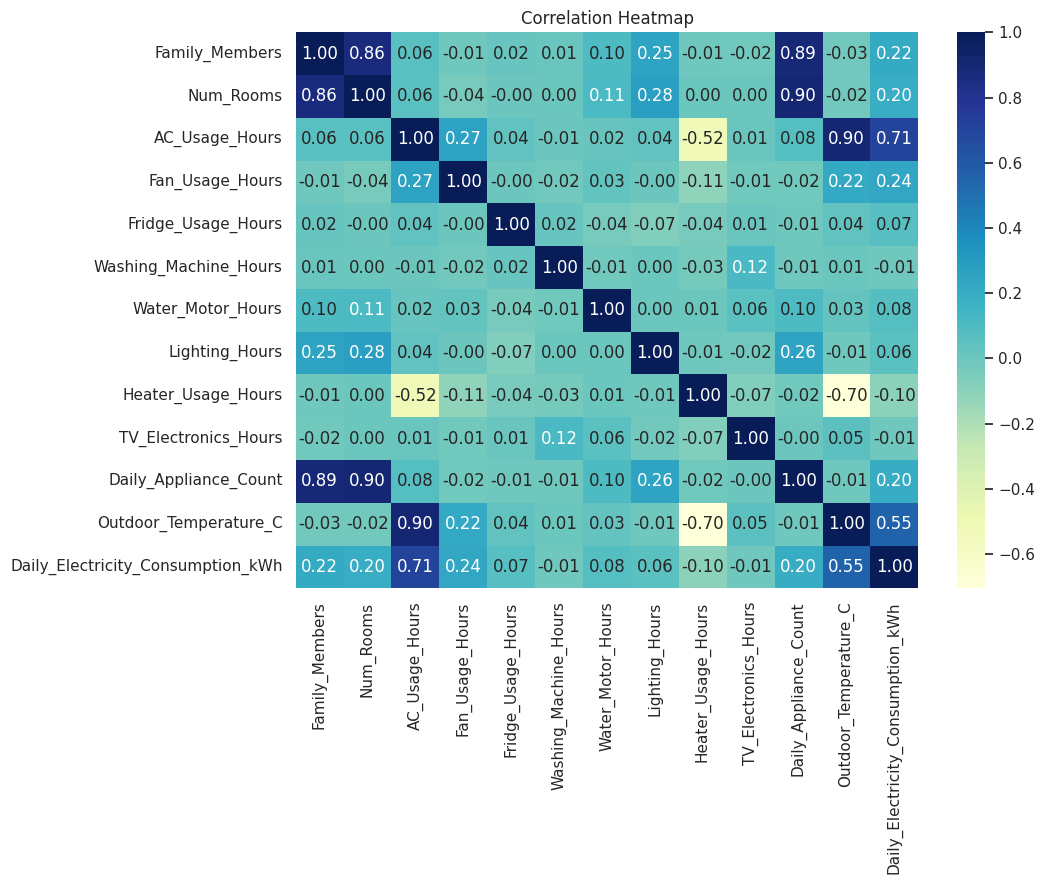

In [6]:
plt.figure(figsize=(11,9))
corr = df_processed[[
    'Family_Members','Num_Rooms','AC_Usage_Hours','Fan_Usage_Hours',
    'Fridge_Usage_Hours','Washing_Machine_Hours','Water_Motor_Hours',
    'Lighting_Hours','Heater_Usage_Hours','TV_Electronics_Hours',
    'Daily_Appliance_Count','Outdoor_Temperature_C',
    'Daily_Electricity_Consumption_kWh'
]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


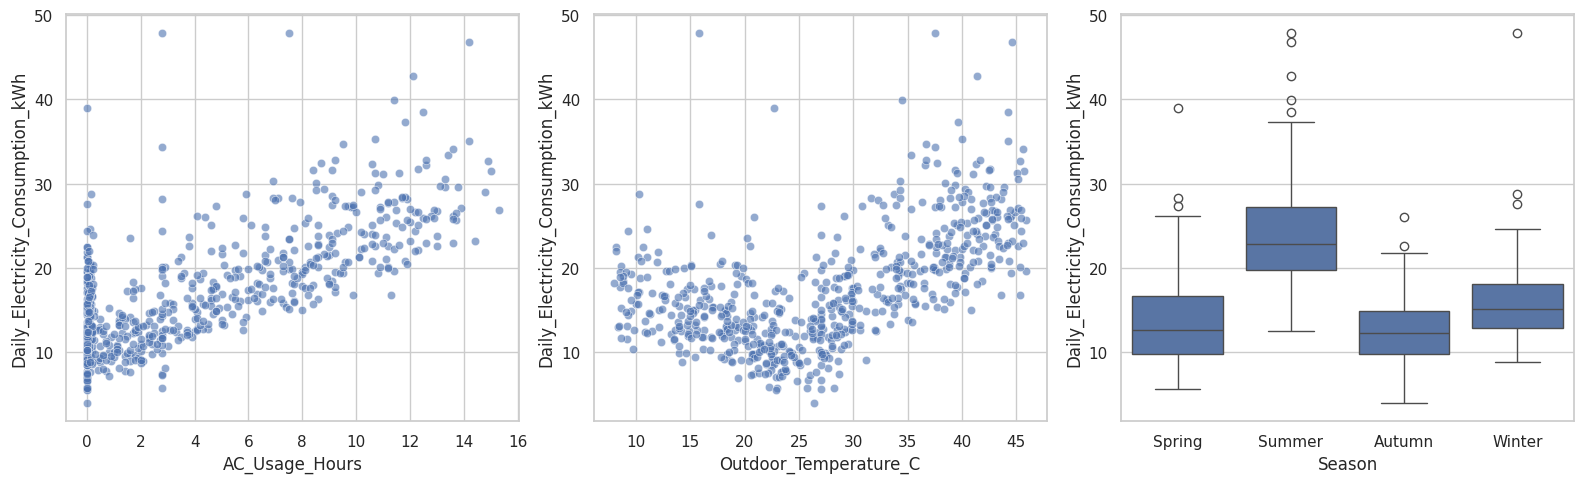

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.scatterplot(x='AC_Usage_Hours', y='Daily_Electricity_Consumption_kWh', data=df_processed, ax=axes[0], alpha=0.6)
sns.scatterplot(x='Outdoor_Temperature_C', y='Daily_Electricity_Consumption_kWh', data=df_processed, ax=axes[1], alpha=0.6)
sns.boxplot(x='Season', y='Daily_Electricity_Consumption_kWh', data=df_processed, ax=axes[2])
plt.tight_layout()
plt.show()


**Business Insights:**
- AC usage hours and outdoor temperature show the strongest positive correlation with daily electricity consumption.
- Larger families and homes with more rooms consume more electricity overall.
- Summer season shows the highest average consumption due to AC-driven cooling load.


## 4. Feature Engineering

In [8]:
from feature_engineering import engineer_features, evaluate_feature_importance

df_feat, features = engineer_features(df_processed)
importance = evaluate_feature_importance(df_feat, features)
importance.head(10)


High_Power_Load_Index    0.456461
House_Type_Encoded       0.148982
Outdoor_Temperature_C    0.091569
Temp_AC_Interaction      0.090850
AC_Usage_Hours           0.056925
Fan_Usage_Hours          0.023152
Lighting_Hours           0.016929
Washing_Machine_Hours    0.015125
Family_Members           0.015096
Appliance_Density        0.013677
dtype: float64

## 5. Model Training & Comparison

Six regression algorithms are trained and compared: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and Support Vector Regression.

In [9]:
from train_models import main as train_main

results_df, best_model_name = train_main()
results_df


,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression,1.834,5.623,2.371,0.8479
1,Gradient Boosting,1.898,6.805,2.609,0.8159
2,XGBoost,1.901,6.851,2.618,0.8147
3,Random Forest,1.948,7.280,2.698,0.8031
4,Support Vector Regression,2.127,7.830,2.798,0.7882
5,Decision Tree,2.344,13.872,3.724,0.6248


In [10]:
print("Best performing model:", best_model_name)


Best performing model: Linear Regression


## 6. Model Evaluation

See `plots/actual_vs_predicted.png` and `plots/model_comparison.png` for visual evaluation of the best model versus alternatives.

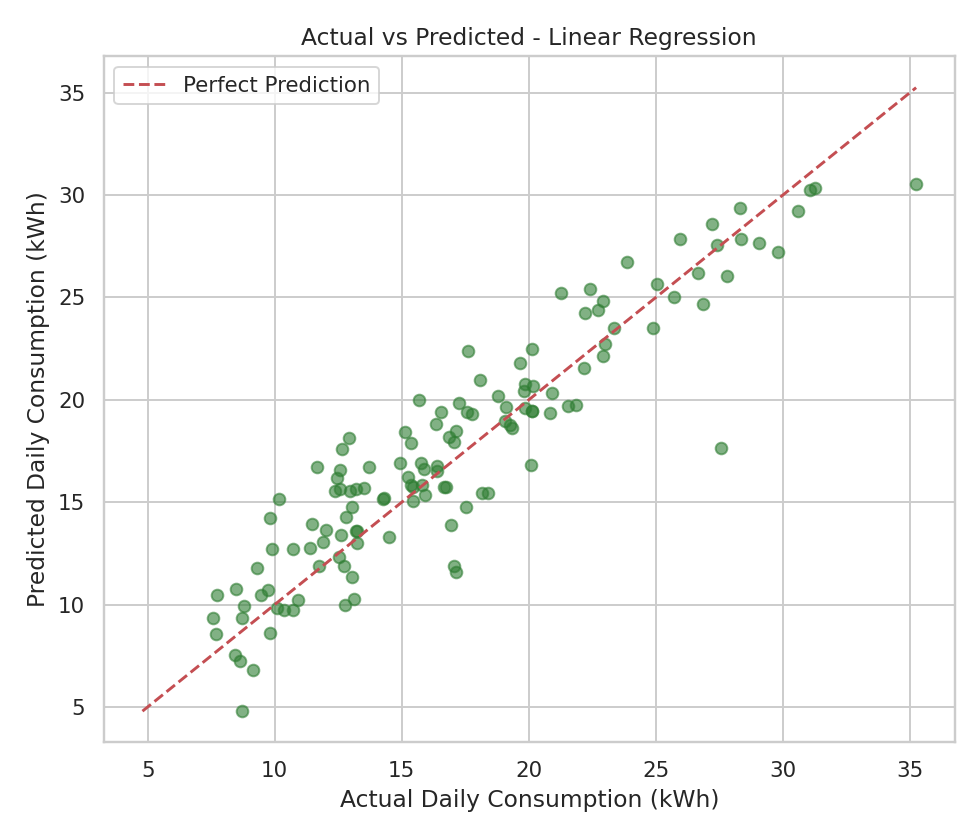

In [11]:
from IPython.display import Image
Image(filename='../plots/actual_vs_predicted.png')


## 7. Prediction System & Energy Optimization Recommendations

A sample prediction using the trained model, demonstrating the full recommendation engine output.

In [12]:
import joblib
from recommendations import generate_recommendations

model = joblib.load('../models/best_model.pkl')
feature_list = joblib.load('../models/feature_list.pkl')
encoders = joblib.load('../models/label_encoders.pkl')

sample = {
    'Family_Members': 5, 'Num_Rooms': 4, 'AC_Usage_Hours': 7, 'Fan_Usage_Hours': 12,
    'Fridge_Usage_Hours': 22, 'Washing_Machine_Hours': 1, 'Water_Motor_Hours': 1.5,
    'Lighting_Hours': 8, 'Heater_Usage_Hours': 2, 'TV_Electronics_Hours': 5,
    'Daily_Appliance_Count': 10, 'Outdoor_Temperature_C': 38,
    'House_Type_Encoded': encoders['House_Type'].transform(['Independent House'])[0],
    'Day_of_Week_Encoded': encoders['Day_of_Week'].transform(['Saturday'])[0],
    'Season_Encoded': encoders['Season'].transform(['Summer'])[0],
    'Is_Working_Day': 0,
}

sample_df = pd.DataFrame([sample])
sample_df, _ = engineer_features(sample_df)
prediction = model.predict(sample_df[feature_list])[0]

result = generate_recommendations(sample, prediction)
print(f"Predicted Daily Consumption: {prediction:.2f} kWh")
print(f"Estimated Monthly Usage: {result['estimated_monthly_kwh']} kWh")
print(f"Estimated Monthly Bill: PKR {result['estimated_monthly_bill_pkr']}")
print(f"Efficiency Score: {result['efficiency_score']}/100")
print("Peak Hours:", result['peak_hours'])
print("Recommendations:")
for r in result['recommendations']:
    print(" -", r)


Predicted Daily Consumption: 25.77 kWh
Estimated Monthly Usage: 773.05 kWh
Estimated Monthly Bill: PKR 34787.09
Efficiency Score: 0/100
Peak Hours: ['2:00 PM - 6:00 PM (AC-driven afternoon peak)', '9:00 AM - 11:00 AM (Laundry peak)']
Recommendations:
 - AC usage is high — raising the thermostat by 1-2°C or reducing usage by 1 hour/day can meaningfully cut consumption.


## 8. Conclusion

This notebook demonstrates the complete machine learning lifecycle for the Smart Electricity
Consumption Prediction & Energy Optimization System: from original synthetic dataset creation
through preprocessing, EDA, feature engineering, multi-model comparison, evaluation, and a
working prediction + recommendation system. See `reports/` for the full Excel/PDF reports and
`src/app.py` for the interactive Streamlit deployment.
